# Gaussian Naïve Bayes (GNB)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

GNB_FEATURES = [f for f in FEATURES if f not in ("P_GRAVITY", "P_DENSITY", "P_ESCAPE")]

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df, features=GNB_FEATURES
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 328 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    200
Name: count, dtype: int64
Balanced train shape: (700, 14)
Class weights: {np.int64(0): np.float64(0.7777777777777778), np.int64(1): np.float64(1.1666666666666667), np.int64(2): np.float64(1.1666666666666667)}

Outputs ready for modeling:
  X_train_bal       → (700, 14) (balanced, scaled)
  y_train_bal       → 700 samples
  X_test_scaled     → (1114, 14) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# GAUSSIAN NAÏVE BAYES (GNB) — Baseline Classifier
# ══════════════════════════════════════════════════════════════════════════════
# GNB assumes features are independent and normally distributed per class.
# It has no class_weight parameter, so it relies entirely on the balanced
# training data from SMOTE. Expected to be the weakest model — sets the floor.

# ── Step 1: Tune var_smoothing ──
param_grid = {"var_smoothing": np.logspace(-12, -1, 25)}

grid_gnb = run_grid_search(GaussianNB(), param_grid, X_train_bal, y_train_bal)
gnb = grid_gnb.best_estimator_

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)

class_names, classes, colors = get_class_meta()

print("GNB training complete.")
print(f"Best var_smoothing: {grid_gnb.best_params_['var_smoothing']:.2e}")
print(f"Best CV F1 Macro:   {grid_gnb.best_score_:.4f}")

GNB training complete.
Best var_smoothing: 1.00e-12
Best CV F1 Macro:   0.8851


### Seed-Sweep Evaluation

Grid search above tuned `var_smoothing` on `random_state=42` only. The single test F1 macro from one split is a noisy estimate when minority test classes have only 6 mesoplanet and 8 psychroplanet samples. Re-evaluate with the tuned hyperparameter across 50 random splits, capturing per-seed confusion matrices and predicted probabilities for downstream aggregated diagnostics.

GNB-specific: the sweep must pass `features=GNB_FEATURES` so each seed's `split_and_balance` drops the three derived columns (`P_GRAVITY`, `P_DENSITY`, `P_ESCAPE`) — they're deterministic functions of mass and radius, violating GNB's feature-independence assumption. The class-conditional Gaussian plots above stay at seed=42 — they're model-internals showing what GNB learned on one specific training set, and the qualitative story doesn't change across seeds.

In [4]:
sweep_gnb = run_seed_sweep(
    lambda cw: GaussianNB(**grid_gnb.best_params_),
    df,
    n_seeds=50,
    features=GNB_FEATURES,
    model_name="GNB",
    save_csv="sweep_gnb.csv",
    save_pickle="sweep_gnb.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

GNB — 50-seed sweep
  F1 macro:    0.5694 ± 0.0403  (SEM 0.0057, min 0.4830, max 0.6782)
  F1 weighted: 0.9733 ± 0.0035
  Captured per-seed: predict_proba
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_gnb.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_gnb.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Class-Conditional Gaussian Distributions (Top 6 Features)

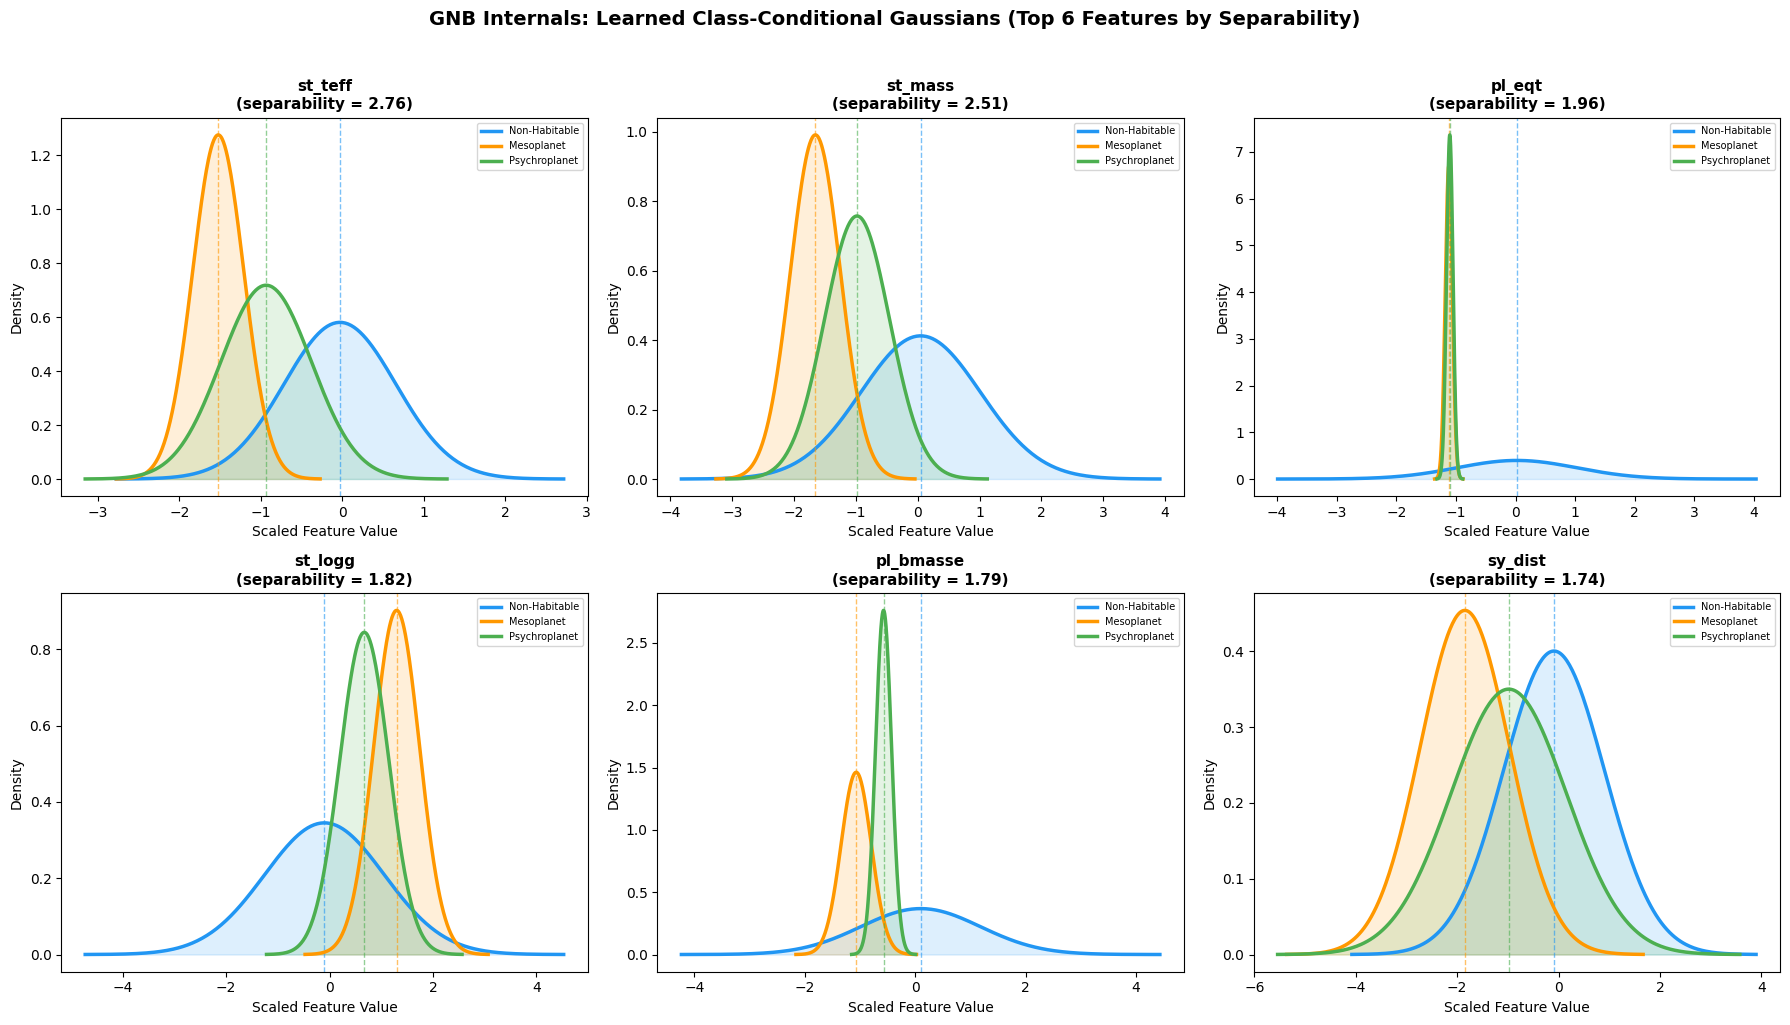

↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.


In [5]:
separability = []
for j, feat in enumerate(GNB_FEATURES):
    means = gnb.theta_[:, j]
    varis = gnb.var_[:, j]
    spread = means.max() - means.min()
    pooled_std = np.sqrt(np.mean(varis))
    separability.append((spread / (pooled_std + 1e-12), feat, j))

separability.sort(reverse=True)
top_features = separability[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax_idx, (sep_score, feat_name, feat_idx) in enumerate(top_features):
    ax = axes[ax_idx]

    for c in range(3):
        mu = gnb.theta_[c, feat_idx]
        sigma = np.sqrt(gnb.var_[c, feat_idx])

        x_range = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        pdf = norm.pdf(x_range, mu, sigma)

        ax.plot(x_range, pdf, color=colors[c], lw=2.5, label=class_names[c])
        ax.fill_between(x_range, pdf, alpha=0.15, color=colors[c])
        ax.axvline(mu, color=colors[c], ls="--", lw=1, alpha=0.6)

    ax.set_title(f"{feat_name}\n(separability = {sep_score:.2f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Scaled Feature Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("GNB Internals: Learned Class-Conditional Gaussians (Top 6 Features by Separability)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("gnb_class_conditionals")
plt.show()

print("↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.")

### DIAGNOSTIC PLOT 2: Predicted Posterior Probability Distributions by True Class

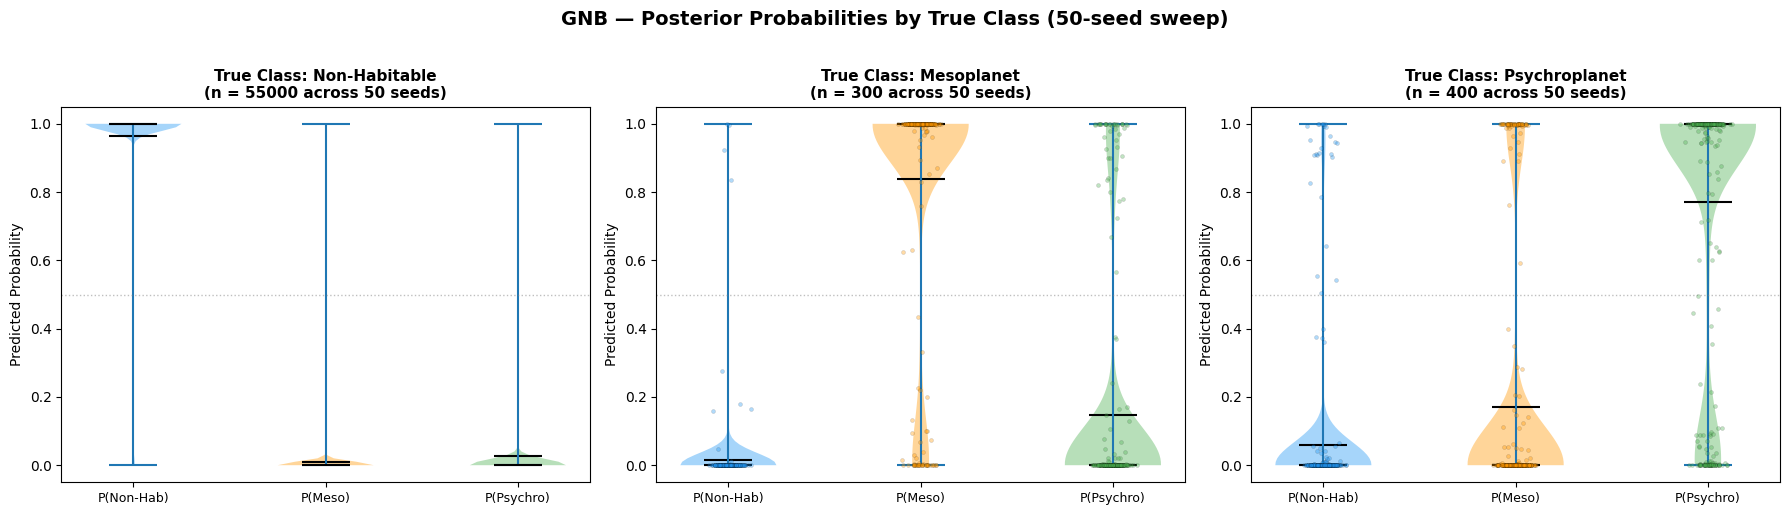

↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 probability
  points per minority panel, the violins now carry real statistical mass — unlike the single-
  split version where 6–8 samples produced uninformative shapes.
  A well-calibrated GNB concentrates P(true class) near 1.0 across most splits.
  Wide spreads on minority panels are expected — GNB's feature-independence assumption
  limits how confidently it can separate the minority classes from non-habitable.


In [6]:
plot_sweep_posterior_violins(sweep_gnb)

print("↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 probability")
print("  points per minority panel, the violins now carry real statistical mass — unlike the single-")
print("  split version where 6–8 samples produced uninformative shapes.")
print("  A well-calibrated GNB concentrates P(true class) near 1.0 across most splits.")
print("  Wide spreads on minority panels are expected — GNB's feature-independence assumption")
print("  limits how confidently it can separate the minority classes from non-habitable.")

## Metrics
### Classification Report

GNB — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9812     0.0030     0.9748     0.9876
Mesoplanet           0.4456     0.1004     0.1905     0.7143
Psychroplanet        0.2813     0.0553     0.1600     0.4211
----------------------------------------------------------------
Macro avg            0.5694     0.0403     0.4830     0.6782
Weighted avg         0.9733     0.0035     0.9669     0.9809

5-Fold CV F1 Macro: 0.8853 ± 0.0140

GNB — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9995 ± 0.0007    0.9637 ± 0.0060
Mesoplanet       0.3091 ± 0.0856    0.8367 ± 0.1733
Psychroplanet    0.1730 ± 0.0366    0.7725 ± 0.1466
----------------------------------------------------------------
Macro avg        0.4939 ± 0.0322    0.8576 ± 0.0655
Wei

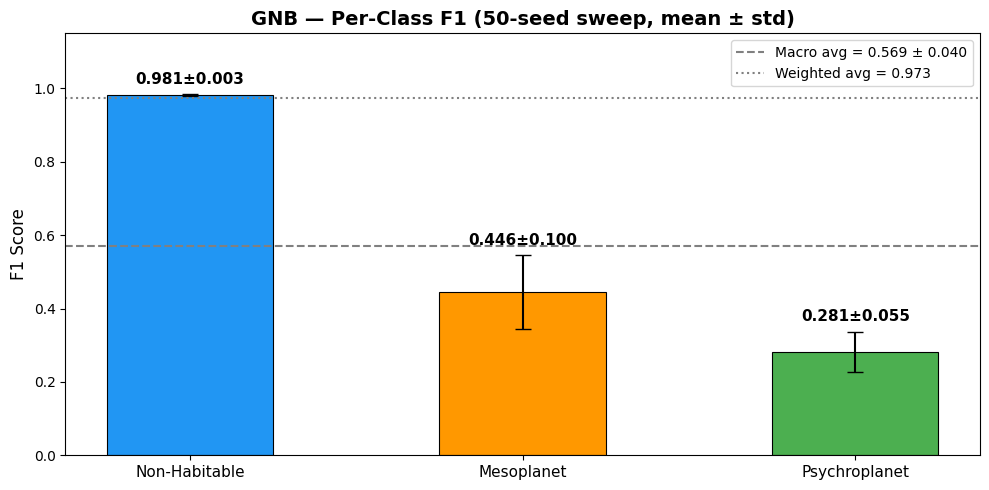

In [7]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_gnb)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_gnb = run_stratified_cv(gnb, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_gnb)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_gnb)

### Confusion Matrices (Counts + Normalized)

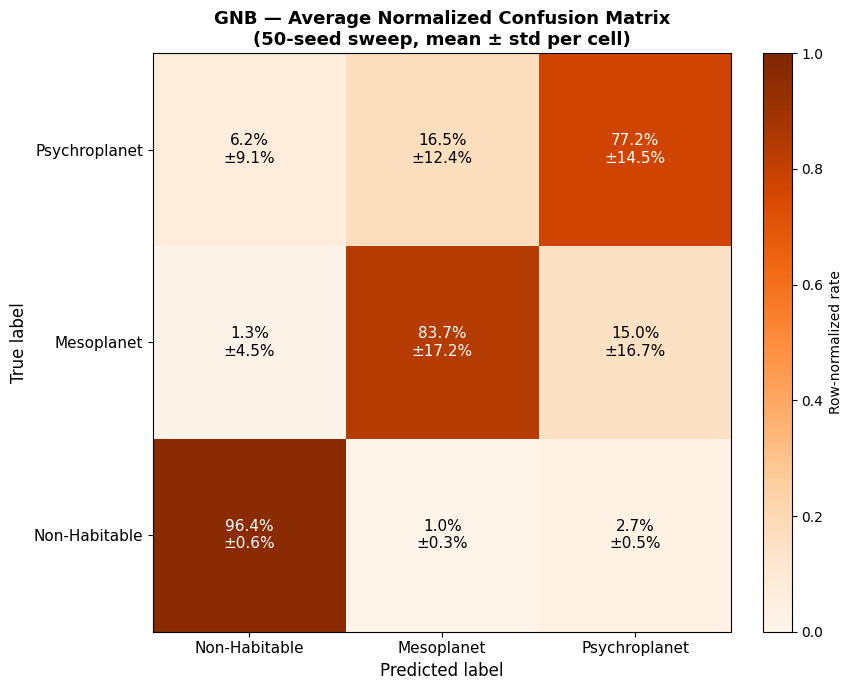

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 10.58 ± 3.59 per split  (1.0% ± 0.3% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 29.38 ± 6.02 per split  (2.7% ± 0.5% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.08 ± 0.27 per split  (1.3% ± 4.5% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.90 ± 1.00 per split  (15.0% ± 16.7% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 0.50 ± 0.73 per split  (6.2% ± 9.1% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1.32 ± 0.99 per split  (16.5% ± 12.4% of true Psychroplanet)


In [8]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_gnb)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_gnb)

## Interpretation
